In [1]:
import numpy as np
import sympy as sp
from full_gddegp.gddegp import gddegp
from scipy.stats import qmc
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import utils

plt.rcParams.update({'font.size': 12})

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
n_order = 1
n_bases = 2
num_training_pts = 20
domain_bounds = ((-5.0, 10.0), (0.0, 15.0))
test_grid_resolution = 100
normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
random_seed = 1
np.random.seed(random_seed)

print("Configuration complete!")
print(f"Number of training points: {num_training_pts}")
print(f"Domain bounds: x ∈ {domain_bounds[0]}, y ∈ {domain_bounds[1]}")

Configuration complete!
Number of training points: 20
Domain bounds: x ∈ (-5.0, 10.0), y ∈ (0.0, 15.0)


In [3]:
# Define symbolic Branin function
x_sym, y_sym = sp.symbols('x y')
a, b, c, r, s, t = 1.0, 5.1/(4*sp.pi**2), 5.0/sp.pi, 6.0, 10.0, 1.0/(8*sp.pi)
f_sym = a * (y_sym - b*x_sym**2 + c*x_sym - r)**2 + s*(1 - t)*sp.cos(x_sym) + s

# Compute symbolic gradients
grad_x_sym = sp.diff(f_sym, x_sym)
grad_y_sym = sp.diff(f_sym, y_sym)

# Convert to NumPy functions
true_function_np = sp.lambdify([x_sym, y_sym], f_sym, 'numpy')
grad_x_func = sp.lambdify([x_sym, y_sym], grad_x_sym, 'numpy')
grad_y_func = sp.lambdify([x_sym, y_sym], grad_y_sym, 'numpy')

def true_function(X, alg=np):
    """2D Branin function."""
    return true_function_np(X[:, 0], X[:, 1])

def true_gradient(x, y):
    """Analytical gradient of the Branin function."""
    gx = grad_x_func(x, y)
    gy = grad_y_func(x, y)
    return gx, gy

print("Branin function and analytical gradients defined!")

Branin function and analytical gradients defined!


In [4]:
def clipped_arrow(ax, origin, direction, length, bounds, color="black"):
    """Draw an arrow clipped to plot bounds."""
    x0, y0 = origin
    dx, dy = direction * length
    xlim, ylim = bounds
    tx = np.inf if dx == 0 else (
        xlim[1] - x0)/dx if dx > 0 else (xlim[0] - x0)/dx
    ty = np.inf if dy == 0 else (
        ylim[1] - y0)/dy if dy > 0 else (ylim[0] - y0)/dy
    t = min(1.0, tx, ty)
    ax.arrow(x0, y0, dx*t, dy*t, head_width=0.25,
             head_length=0.35, fc=color, ec=color)

print("Arrow clipping utility defined!")

Arrow clipping utility defined!


In [5]:
# 1. Generate points using Latin Hypercube
sampler = qmc.LatinHypercube(d=n_bases, seed=random_seed)
unit_samples = sampler.random(n=num_training_pts)
X_train = qmc.scale(unit_samples,
                    [b[0] for b in domain_bounds],
                    [b[1] for b in domain_bounds])

# 2. Compute gradient-aligned rays at each training point
rays_list = []
for i, (x, y) in enumerate(X_train):
    gx, gy = true_gradient(x, y)
    # Normalize to unit vector
    magnitude = np.sqrt(gx**2 + gy**2)
    ray = np.array([[gx/magnitude], [gy/magnitude]])
    rays_list.append(ray)

# 3. Compute function values at training points
y_func = true_function(X_train).reshape(-1, 1)

# 4. Compute directional derivatives using the chain rule
# For each point: d_ray = grad_x * ray[0] + grad_y * ray[1]
directional_derivs = []
for i, (x, y) in enumerate(X_train):
    gx, gy = true_gradient(x, y)
    ray_direction = rays_list[i].flatten()
    # Directional derivative = gradient · direction
    dir_deriv = gx * ray_direction[0] + gy * ray_direction[1]
    directional_derivs.append(dir_deriv)

# Stack all directional derivatives into a single array
directional_derivs_array = np.array(directional_derivs).reshape(-1, 1)

# 5. Package training data
# y_train_list should be a list of two arrays, each of shape [num_training_pts, 1]
y_train_list = [y_func, directional_derivs_array]
der_indices = [[[1, 1]]]

print(f"Training data generated!")
print(f"X_train shape: {X_train.shape}")
print(f"Function values shape: {y_func.shape}")
print(f"Directional derivatives shape: {directional_derivs_array.shape}")
print(f"Number of unique ray directions: {len(rays_list)}")
print("\nExample ray directions (first 3 points):")
for i in range(min(3, num_training_pts)):
    ray = rays_list[i].flatten()
    angle = np.arctan2(ray[1], ray[0]) * 180 / np.pi
    print(f"  Point {i}: [{ray[0]:+.4f}, {ray[1]:+.4f}] (angle: {angle:.1f}°)")

Training data generated!
X_train shape: (20, 2)
Function values shape: (20, 1)
Directional derivatives shape: (20, 1)
Number of unique ray directions: 20

Example ray directions (first 3 points):
  Point 0: [+0.9418, +0.3361] (angle: 19.6°)
  Point 1: [+0.9408, -0.3391] (angle: -19.8°)
  Point 2: [-0.6352, +0.7724] (angle: 129.4°)


In [6]:
# Convert rays_list to array format for GDDEGP
# Stack rays horizontally: each column is a ray
rays_array = np.hstack(rays_list)  # Shape: (2, num_training_pts)

print(f"Rays array shape: {rays_array.shape}")
print("Initializing GDDEGP model...")

# Initialize GDDEGP model
gp_model = gddegp(
    X_train,
    y_train_list,
    n_order=[n_order],
    der_indices=der_indices,
    rays_array=[rays_array],
    normalize=normalize_data,
    kernel=kernel,
    kernel_type=kernel_type
)

print("GDDEGP model initialized!")
print("Optimizing hyperparameters...")

# Optimize hyperparameters
params = gp_model.optimize_hyperparameters(
    optimizer='pso',
    pop_size=200,
    n_generations=15,
    local_opt_every=None,
    debug=False
)

print("Optimization complete!")
print(f"Optimized parameters: {params}")

Rays array shape: (2, 20)
Initializing GDDEGP model...
GDDEGP model initialized!
Optimizing hyperparameters...


Stopping: maximum iterations reached --> 15
Optimization complete!
Optimized parameters: [ -0.10057311  -1.29265837   1.94010282 -12.16000727]


In [7]:
# Create test grid
gx = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
gy = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
X1_grid, X2_grid = np.meshgrid(gx, gy)
X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
N_test = X_test.shape[0]

print(f"Test grid: {test_grid_resolution}×{test_grid_resolution} = {N_test} points")

# For prediction, we need dummy rays (not used in function value prediction)
dummy_ray = np.array([[1.0], [0.0]])
rays_pred = np.hstack([dummy_ray for _ in range(N_test)])

print("Making predictions...")
y_pred_full = gp_model.predict(
    X_test, [rays_pred], params, calc_cov=False, return_deriv=True)
y_pred = y_pred_full[:N_test]  # Function values only

# Compute ground truth and error
y_true = true_function(X_test, alg=np)
nrmse_val = utils.nrmse(y_true.flatten(), y_pred.flatten())

print(f"\nModel Performance:")
print(f"  NRMSE: {nrmse_val:.6f}")
abs_error = np.abs(y_true.flatten() - y_pred.flatten())
print(f"  Max absolute error: {abs_error.max():.6f}")
print(f"  Mean absolute error: {abs_error.mean():.6f}")

Test grid: 100×100 = 10000 points
Making predictions...



Model Performance:
  NRMSE: 0.000139
  Max absolute error: 0.442733
  Mean absolute error: 0.012534


In [8]:
# ------------------------------------------------------------
# Verify function value interpolation at all training points
# ------------------------------------------------------------
y_func_values = y_train_list[0]  # Function values

# Prepare rays for prediction at training points
rays_train = np.hstack(rays_list)  # Shape: (2, num_training_pts)

# Predict at training points with derivatives
y_pred_train_full = gp_model.predict(
    X_train, [rays_train], params, calc_cov=False, return_deriv=True
)

# Extract function values (first num_training_pts entries)
y_pred_train_func = y_pred_train_full[:num_training_pts]

print("Function value interpolation errors:")
print("=" * 80)
for i in range(num_training_pts):
    error_abs = abs(y_pred_train_func[i, 0] - y_func_values[i, 0])
    error_rel = error_abs / abs(y_func_values[i, 0]) if y_func_values[i, 0] != 0 else error_abs
    print(f"Point {i} (x={X_train[i, 0]:.4f}, y={X_train[i, 1]:.4f}): "
          f"Abs Error = {error_abs:.2e}, Rel Error = {error_rel:.2e}")

max_func_error = np.max(np.abs(y_pred_train_func - y_func_values))
print(f"\nMaximum absolute function value error: {max_func_error:.2e}")

# ------------------------------------------------------------
# Verify directional derivative interpolation
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("Directional derivative interpolation verification:")
print("=" * 80)
print("Note: Each training point has a DIFFERENT gradient-aligned direction")
print("=" * 80)

# Extract predicted derivatives (entries after function values)
y_pred_train_derivs = y_pred_train_full[num_training_pts:]

# Extract analytic derivatives from training data
analytic_derivs = y_train_list[1]

print(f"\nPrediction with derivatives shape: {y_pred_train_full.shape}")
print(f"Expected: {num_training_pts} function values + {num_training_pts} derivatives = {2 * num_training_pts}")
print(f"Predicted derivatives shape: {y_pred_train_derivs.shape}")
print(f"Analytic derivatives shape: {analytic_derivs.shape}")

# Verify each point's directional derivative
for i in range(num_training_pts):
    ray_direction = rays_list[i].flatten()
    angle_deg = np.arctan2(ray_direction[1], ray_direction[0]) * 180 / np.pi

    error_abs = abs(y_pred_train_derivs[i, 0] - analytic_derivs[i, 0])
    error_rel = error_abs / abs(analytic_derivs[i, 0]) if analytic_derivs[i, 0] != 0 else error_abs

    print(f"\nPoint {i} (x={X_train[i, 0]:.4f}, y={X_train[i, 1]:.4f}):")
    print(f"  Ray direction: [{ray_direction[0]:+.6f}, {ray_direction[1]:+.6f}] (angle: {angle_deg:.1f}°)")
    print(f"  Analytic: {analytic_derivs[i, 0]:+.6f}, Predicted: {y_pred_train_derivs[i, 0]:+.6f}")
    print(f"  Abs Error: {error_abs:.2e}, Rel Error: {error_rel:.2e}")

max_deriv_error = np.max(np.abs(y_pred_train_derivs - analytic_derivs))
print(f"\n{'='*80}")
print(f"Maximum absolute derivative error: {max_deriv_error:.2e}")


print("\n" + "=" * 80)
print("Interpolation verification complete!")
print("Relative errors should be close to machine precision (< 1e-6)")
print("\n" + "=" * 80)
print("SUMMARY:")
print(f"  - Function values: enforced at all {num_training_pts} training points")
print(f"  - Directional derivatives: ONE unique direction per training point")
print(f"  - Total constraints: {num_training_pts} function values + {num_training_pts} directional derivatives")
print(f"  - Direction strategy: GRADIENT-ALIGNED (each ray points along local gradient)")
print(f"  - Prediction vector structure: [func_vals ({num_training_pts}), derivs ({num_training_pts})]")
print("  - Key difference from DDEGP: Each point has a DIFFERENT direction")
print("=" * 80)

Function value interpolation errors:
Point 0 (x=-0.8839, y=11.2872): Abs Error = 8.59e-06, Rel Error = 2.83e-07
Point 1 (x=3.8919, y=0.7885): Abs Error = 8.57e-06, Rel Error = 2.18e-06
Point 2 (x=7.5161, y=10.9325): Abs Error = 3.00e-06, Rel Error = 2.85e-08
Point 3 (x=-2.6208, y=4.1931): Abs Error = 2.88e-07, Rel Error = 5.91e-09
Point 4 (x=5.8378, y=5.2293): Abs Error = 2.83e-06, Rel Error = 7.95e-08
Point 5 (x=4.9349, y=7.8464): Abs Error = 1.52e-06, Rel Error = 2.76e-08
Point 6 (x=6.7527, y=12.9087): Abs Error = 2.42e-06, Rel Error = 1.54e-08
Point 7 (x=1.5226, y=6.4099): Abs Error = 6.61e-06, Rel Error = 3.92e-07
Point 8 (x=-2.8505, y=9.4477): Abs Error = 3.68e-06, Rel Error = 6.85e-07
Point 9 (x=0.0974, y=2.8033): Abs Error = 4.63e-06, Rel Error = 1.61e-07
Point 10 (x=7.9372, y=8.7897): Abs Error = 5.91e-06, Rel Error = 9.49e-08
Point 11 (x=-4.6139, y=1.5144): Abs Error = 3.51e-06, Rel Error = 1.58e-08
Point 12 (x=-1.9712, y=12.2064): Abs Error = 2.40e-06, Rel Error = 1.87e-07
Po

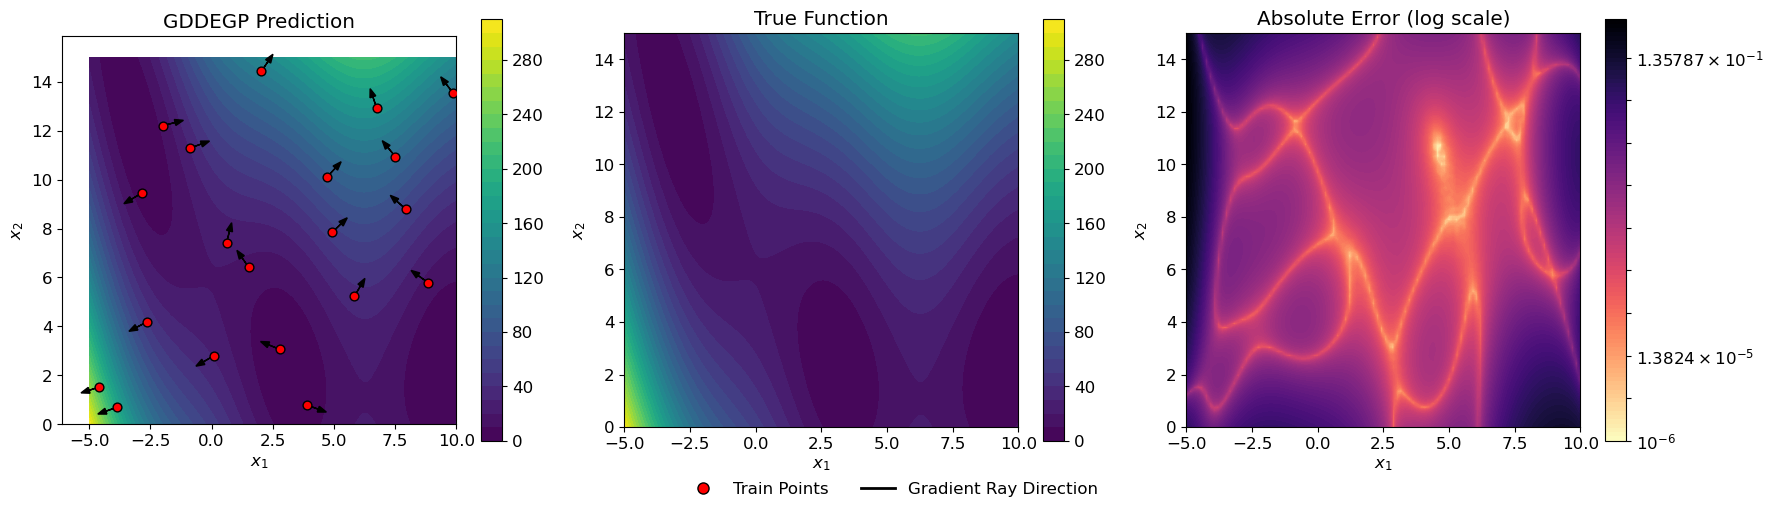


Final NRMSE: 0.000139


In [9]:
# Prepare visualization data
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# GDDEGP Prediction
cf1 = axs[0].contourf(X1_grid, X2_grid, y_pred.reshape(X1_grid.shape),
                       levels=30, cmap='viridis')
axs[0].scatter(X_train[:, 0], X_train[:, 1], c='red', s=40,
               edgecolors='k', zorder=5)
xlim, ylim = (domain_bounds[0], domain_bounds[1])
for pt, ray in zip(X_train, rays_list):
    clipped_arrow(axs[0], pt, ray.flatten(), length=0.5,
                  bounds=(xlim, ylim), color="black")
axs[0].set_title("GDDEGP Prediction")
fig.colorbar(cf1, ax=axs[0])

# True function
cf2 = axs[1].contourf(X1_grid, X2_grid, y_true.reshape(X1_grid.shape),
                       levels=30, cmap='viridis')
axs[1].set_title("True Function")
fig.colorbar(cf2, ax=axs[1])

# Absolute Error (log scale)
abs_error = np.abs(y_pred.flatten() - y_true.flatten()).reshape(X1_grid.shape)
abs_error_clipped = np.clip(abs_error, 1e-6, None)
log_levels = np.logspace(np.log10(abs_error_clipped.min()),
                         np.log10(abs_error_clipped.max()), num=100)
cf3 = axs[2].contourf(X1_grid, X2_grid, abs_error_clipped, levels=log_levels,
                       norm=LogNorm(), cmap="magma_r")
fig.colorbar(cf3, ax=axs[2])
axs[2].set_title("Absolute Error (log scale)")

for ax in axs:
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")

custom_lines = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markeredgecolor='k', markersize=8, label='Train Points'),
    Line2D([0], [0], color='black', lw=2, label='Gradient Ray Direction'),
]
fig.legend(handles=custom_lines, loc='lower center', ncol=2,
           frameon=False, fontsize=12, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print(f"\nFinal NRMSE: {nrmse_val:.6f}")

In [10]:
import numpy as np
import pyoti.sparse as oti
import itertools
from full_gddegp.gddegp import gddegp
from scipy.stats import qmc
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import utils

plt.rcParams.update({'font.size': 12})

In [11]:
n_order = 1
n_bases = 2
num_directions_per_point = 2
num_training_pts = 10
domain_bounds = ((-5.0, 10.0), (0.0, 15.0))
test_grid_resolution = 50
normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
random_seed = 1
np.random.seed(random_seed)

print("Configuration complete!")
print(f"Number of training points: {num_training_pts}")
print(f"Directions per point: {num_directions_per_point}")
print(f"Total derivative observations: {num_training_pts * num_directions_per_point}")

Configuration complete!
Number of training points: 10
Directions per point: 2
Total derivative observations: 20


In [12]:
def true_function(X, alg=np):
    """Branin function compatible with both NumPy and pyoti arrays."""
    x, y = X[:, 0], X[:, 1]
    a, b, c, r, s, t = 1.0, 5.1/(4*np.pi**2), 5.0/np.pi, 6.0, 10.0, 1.0/(8*np.pi)
    return a*(y - b*x**2 + c*x - r)**2 + s*(1-t)*alg.cos(x) + s

def true_gradient(x, y):
    """Analytical gradient of the Branin function."""
    a, b, c, r, s, t = 1.0, 5.1/(4*np.pi**2), 5.0/np.pi, 6.0, 10.0, 1.0/(8*np.pi)
    gx = 2*a*(y - b*x**2 + c*x - r)*(-2*b*x + c) - s*(1-t)*np.sin(x)
    gy = 2*a*(y - b*x**2 + c*x - r)
    return gx, gy

print("Branin function and analytical gradient defined!")

Branin function and analytical gradient defined!


In [13]:
def clipped_arrow(ax, origin, direction, length, bounds, color="black"):
    """Draw an arrow clipped to plot bounds."""
    x0, y0 = origin
    dx, dy = direction * length
    xlim, ylim = bounds
    tx = np.inf if dx == 0 else (xlim[1] - x0)/dx if dx > 0 else (xlim[0] - x0)/dx
    ty = np.inf if dy == 0 else (ylim[1] - y0)/dy if dy > 0 else (ylim[0] - y0)/dy
    t = min(1.0, tx, ty)
    ax.arrow(x0, y0, dx*t, dy*t, head_width=0.25, head_length=0.35, fc=color, ec=color)

print("Arrow clipping utility defined!")

Arrow clipping utility defined!


In [14]:
print("Generating training data with multiple directional derivatives per point...")

import sympy as sp

# 1. Generate training points using Latin Hypercube Sampling
sampler = qmc.LatinHypercube(d=n_bases, seed=random_seed)
unit_samples = sampler.random(n=num_training_pts)
X_train = qmc.scale(unit_samples,
                    [b[0] for b in domain_bounds],
                    [b[1] for b in domain_bounds])

print(f"Generated {num_training_pts} training points using LHS")

# 2. Set up symbolic variables for gradient computation
x_sym, y_sym = sp.symbols('x y', real=True)

# Define your function symbolically (you'll need to adapt this to your actual function)
# For example, if true_function is f(x,y) = x^2 + y^2:
# f_sym = x_sym**2 + y_sym**2

# Compute symbolic gradient
grad_f = [sp.diff(f_sym, x_sym), sp.diff(f_sym, y_sym)]

# Convert to numerical functions for fast evaluation
grad_x_func = sp.lambdify((x_sym, y_sym), grad_f[0], 'numpy')
grad_y_func = sp.lambdify((x_sym, y_sym), grad_f[1], 'numpy')

print(f"Created symbolic gradient functions")

# 3. Create multiple rays per point: gradient + perpendicular
rays_list = [[] for _ in range(num_directions_per_point)]
for x, y in X_train:
    # Compute gradient and its angle
    gx = grad_x_func(x, y)
    gy = grad_y_func(x, y)
    theta_grad = np.arctan2(gy, gx)
    theta_perp = theta_grad + np.pi/2

    # Create unit vectors for both directions
    ray_grad = np.array([np.cos(theta_grad), np.sin(theta_grad)]).reshape(-1, 1)
    ray_perp = np.array([np.cos(theta_perp), np.sin(theta_perp)]).reshape(-1, 1)

    rays_list[0].append(ray_grad)
    rays_list[1].append(ray_perp)

print(f"Created {num_directions_per_point} orthogonal ray directions per training point")

# 4. Compute directional derivatives using SymPy
# Directional derivative = ∇f · direction_vector
dir_deriv_sym = grad_f[0] * sp.Symbol('d_x') + grad_f[1] * sp.Symbol('d_y')

# Create lambdified function for directional derivative
dir_deriv_func = sp.lambdify((x_sym, y_sym, sp.Symbol('d_x'), sp.Symbol('d_y')),
                            dir_deriv_sym, 'numpy')

print("Computed symbolic directional derivative")

# 5. Evaluate function values and directional derivatives at all training points
y_train_list = []

# Function values
f_func = sp.lambdify((x_sym, y_sym), f_sym, 'numpy')
y_values = np.array([f_func(x, y) for x, y in X_train]).reshape(-1, 1)
y_train_list.append(y_values)

# Directional derivatives for each direction
for ray_set in rays_list:
    derivs = []
    for i, (x, y) in enumerate(X_train):
        ray = ray_set[i].flatten()
        deriv = dir_deriv_func(x, y, ray[0], ray[1])
        derivs.append(deriv)
    y_train_list.append(np.array(derivs).reshape(-1, 1))

der_indices = [[[1, 1]], [[2, 1]]]  # Keep for compatibility if needed

print(f"\nTraining data generated!")
print(f"  Function values: {y_train_list[0].shape}")
print(f"  Gradient direction derivatives: {y_train_list[1].shape}")
print(f"  Perpendicular direction derivatives: {y_train_list[2].shape}")

Generating training data with multiple directional derivatives per point...
Generated 10 training points using LHS
Created symbolic gradient functions
Created 2 orthogonal ray directions per training point
Computed symbolic directional derivative

Training data generated!
  Function values: (10, 1)
  Gradient direction derivatives: (10, 1)
  Perpendicular direction derivatives: (10, 1)


In [15]:
print("Initializing GDDEGP model...")

# Convert rays_list to proper format for GDDEGP
# rays_array should be shape (n_bases, num_training_pts * num_directions_per_point)
rays_array = [np.hstack(rays_list[i])
        for i in range(num_directions_per_point)]


# Initialize GDDEGP model
gp_model = gddegp(
    X_train,
    y_train_list,
    n_order=[n_order, n_order],
    der_indices=der_indices,
    rays_array=rays_array,
    normalize=normalize_data,
    kernel=kernel,
    kernel_type=kernel_type
)

print("GDDEGP model initialized!")
print("Optimizing hyperparameters...")

# Optimize hyperparameters
params = gp_model.optimize_hyperparameters(
    optimizer='pso',
    pop_size=250,
    n_generations=15,
    local_opt_every=None,
    debug=False
)

print("Optimization complete!")
print(f"Optimized parameters: {params}")

Initializing GDDEGP model...
GDDEGP model initialized!
Optimizing hyperparameters...


Stopping: maximum iterations reached --> 15
Optimization complete!
Optimized parameters: [ 1.12005254 -3.         -0.2100822  -7.72523813]


In [16]:
print("Evaluating model on test grid...")

# Create test grid
gx = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
gy = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
X1_grid, X2_grid = np.meshgrid(gx, gy)
X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
N_test = X_test.shape[0]

print(f"Test grid: {test_grid_resolution}×{test_grid_resolution} = {N_test} points")

# Dummy rays for prediction (not used for function values)
dummy_ray = np.array([[1.0], [0.0]])
rays_pred = [np.hstack([dummy_ray for _ in range(N_test)])
             for _ in range(num_directions_per_point)]

# Predict function values only
y_pred_full = gp_model.predict(
    X_test, rays_pred, params,
    calc_cov=False, return_deriv=False
)
y_pred = y_pred_full[:N_test]

# Compute error metrics
y_true = true_function(X_test, alg=np)
nrmse = utils.nrmse(y_true.flatten(), y_pred.flatten())

print(f"\nModel Performance:")
print(f"  NRMSE: {nrmse:.6f}")
print(f"  Max absolute error: {np.max(np.abs(y_pred.flatten() - y_true.flatten())):.6f}")
print(f"  Mean absolute error: {np.mean(np.abs(y_pred.flatten() - y_true.flatten())):.6f}")

Evaluating model on test grid...
Test grid: 50×50 = 2500 points

Model Performance:
  NRMSE: 0.189213
  Max absolute error: 230.411817
  Mean absolute error: 45.411109


In [17]:
print("\n" + "=" * 80)
print("Verifying interpolation of training data...")
print("=" * 80)

# ------------------------------------------------------------
# Verify function value interpolation at all training points
# ------------------------------------------------------------
y_func_values = y_train_list[0]  # Function values

# Prepare rays for prediction at training points
rays_train = [np.hstack(rays_list[i]) for i in range(num_directions_per_point)]

# Predict at training points with derivatives
y_pred_train_full = gp_model.predict(
    X_train, rays_train, params, calc_cov=False, return_deriv=True
)

# Extract function values (first num_training_pts entries)
y_pred_train_func = y_pred_train_full[:num_training_pts]

print("\nFunction value interpolation errors:")
print("-" * 80)
for i in range(num_training_pts):
    error_abs = abs(y_pred_train_func[i, 0] - y_func_values[i, 0])
    error_rel = error_abs / abs(y_func_values[i, 0]) if y_func_values[i, 0] != 0 else error_abs
    print(f"Point {i} (x={X_train[i, 0]:.4f}, y={X_train[i, 1]:.4f}): "
          f"Abs Error = {error_abs:.2e}, Rel Error = {error_rel:.2e}")

max_func_error = np.max(np.abs(y_pred_train_func - y_func_values))
print(f"\nMaximum absolute function value error: {max_func_error:.2e}")

# ------------------------------------------------------------
# Verify directional derivative interpolation
# ------------------------------------------------------------
print("\n" + "-" * 80)
print("Directional derivative interpolation verification:")
print("-" * 80)
print(f"Each training point has {num_directions_per_point} directional derivatives:")
print("  Ray 1: Gradient direction")
print("  Ray 2: Perpendicular direction (orthogonal to gradient)")
print("-" * 80)

# Extract predicted derivatives (entries after function values)
y_pred_train_derivs = y_pred_train_full[num_training_pts:]

# Split into derivatives for each direction
n_derivs_per_direction = num_training_pts
pred_deriv_ray1 = y_pred_train_derivs[:n_derivs_per_direction]
pred_deriv_ray2 = y_pred_train_derivs[n_derivs_per_direction:2*n_derivs_per_direction]

# Extract analytic derivatives from training data
analytic_deriv_ray1 = y_train_list[1]  # Gradient derivatives
analytic_deriv_ray2 = y_train_list[2]  # Perpendicular derivatives

print(f"\nPrediction with derivatives shape: {y_pred_train_full.shape}")
print(f"Expected: {num_training_pts} func + {num_training_pts}×{num_directions_per_point} derivs = {num_training_pts * (1 + num_directions_per_point)}")

# Verify gradient direction derivatives (Ray 1)
print(f"\n{'='*80}")
print("RAY 1: GRADIENT DIRECTION")
print(f"{'='*80}")

for i in range(num_training_pts):
    ray_direction = rays_list[0][i].flatten()
    angle_deg = np.arctan2(ray_direction[1], ray_direction[0]) * 180 / np.pi

    error_abs = abs(pred_deriv_ray1[i, 0] - analytic_deriv_ray1[i, 0])
    error_rel = error_abs / abs(analytic_deriv_ray1[i, 0]) if analytic_deriv_ray1[i, 0] != 0 else error_abs

    print(f"\nPoint {i} (x={X_train[i, 0]:.4f}, y={X_train[i, 1]:.4f}):")
    print(f"  Ray direction: [{ray_direction[0]:+.6f}, {ray_direction[1]:+.6f}] (angle: {angle_deg:.1f}°)")
    print(f"  Analytic: {analytic_deriv_ray1[i, 0]:+.6f}, Predicted: {pred_deriv_ray1[i, 0]:+.6f}")
    print(f"  Abs Error: {error_abs:.2e}, Rel Error: {error_rel:.2e}")

max_deriv_error_ray1 = np.max(np.abs(pred_deriv_ray1 - analytic_deriv_ray1))
print(f"\nMaximum absolute error for Ray 1 (gradient): {max_deriv_error_ray1:.2e}")

# Verify perpendicular direction derivatives (Ray 2)
print(f"\n{'='*80}")
print("RAY 2: PERPENDICULAR DIRECTION")
print(f"{'='*80}")

for i in range(num_training_pts):
    ray_direction = rays_list[1][i].flatten()
    angle_deg = np.arctan2(ray_direction[1], ray_direction[0]) * 180 / np.pi

    error_abs = abs(pred_deriv_ray2[i, 0] - analytic_deriv_ray2[i, 0])
    error_rel = error_abs / abs(analytic_deriv_ray2[i, 0]) if analytic_deriv_ray2[i, 0] != 0 else error_abs

    print(f"\nPoint {i} (x={X_train[i, 0]:.4f}, y={X_train[i, 1]:.4f}):")
    print(f"  Ray direction: [{ray_direction[0]:+.6f}, {ray_direction[1]:+.6f}] (angle: {angle_deg:.1f}°)")
    print(f"  Analytic: {analytic_deriv_ray2[i, 0]:+.6f}, Predicted: {pred_deriv_ray2[i, 0]:+.6f}")
    print(f"  Abs Error: {error_abs:.2e}, Rel Error: {error_rel:.2e}")

max_deriv_error_ray2 = np.max(np.abs(pred_deriv_ray2 - analytic_deriv_ray2))
print(f"\nMaximum absolute error for Ray 2 (perpendicular): {max_deriv_error_ray2:.2e}")


print("\n" + "=" * 80)
print("Interpolation verification complete!")
print("Relative errors should be close to machine precision (< 1e-6)")
print("\n" + "=" * 80)
print("SUMMARY:")
print(f"  - Function values: enforced at all {num_training_pts} training points")
print(f"  - Directional derivatives: {num_directions_per_point} unique directions per training point")
print(f"  - Total constraints: {num_training_pts} function values + {num_training_pts * num_directions_per_point} directional derivatives")
print(f"  - Direction types:")
print(f"    * Ray 1: GRADIENT direction (aligned with ∇f)")
print(f"    * Ray 2: PERPENDICULAR direction (orthogonal to ∇f)")
print("=" * 80)


Verifying interpolation of training data...

Function value interpolation errors:
--------------------------------------------------------------------------------
Point 0 (x=7.7323, y=10.5743): Abs Error = 4.26e-14, Rel Error = 4.49e-16
Point 1 (x=9.7838, y=7.5770): Abs Error = 3.55e-14, Rel Error = 1.49e-15
Point 2 (x=-0.9677, y=12.8650): Abs Error = 2.13e-14, Rel Error = 5.01e-16
Point 3 (x=1.2584, y=6.8862): Abs Error = 9.95e-14, Rel Error = 4.94e-15
Point 4 (x=-4.3244, y=1.4587): Abs Error = 1.71e-13, Rel Error = 8.62e-16
Point 5 (x=4.3697, y=9.6928): Abs Error = 1.42e-14, Rel Error = 1.93e-16
Point 6 (x=6.5054, y=1.8174): Abs Error = 4.26e-14, Rel Error = 2.15e-15
Point 7 (x=3.5452, y=3.8198): Abs Error = 5.77e-14, Rel Error = 1.27e-14
Point 8 (x=-2.2011, y=5.3953): Abs Error = 3.55e-14, Rel Error = 1.33e-15
Point 9 (x=0.6948, y=14.6065): Abs Error = 8.53e-14, Rel Error = 7.72e-16

Maximum absolute function value error: 1.71e-13

--------------------------------------------------

Visualizing results...


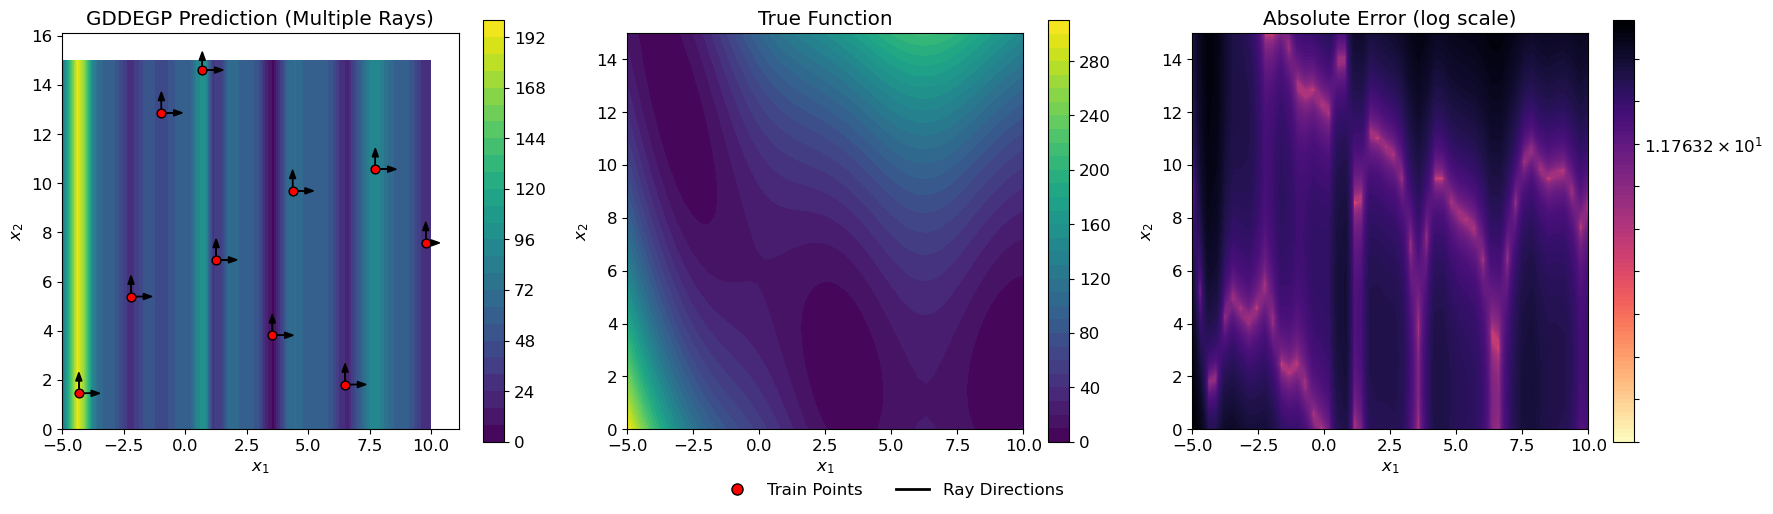


Final NRMSE: 0.189213


In [18]:
print("Visualizing results...")

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# GDDEGP Prediction with multiple rays
cf1 = axs[0].contourf(X1_grid, X2_grid, y_pred.reshape(X1_grid.shape),
                      levels=30, cmap='viridis')
axs[0].scatter(X_train[:, 0], X_train[:, 1], c='red', s=40,
               edgecolors='k', zorder=5)
xlim, ylim = (domain_bounds[0], domain_bounds[1])

# Draw arrows for all directions
for i in range(num_directions_per_point):
    for pt, ray in zip(X_train, rays_list[i]):
        clipped_arrow(axs[0], pt, ray.flatten(), length=0.5,
                     bounds=(xlim, ylim), color='black')

axs[0].set_title("GDDEGP Prediction (Multiple Rays)")
fig.colorbar(cf1, ax=axs[0])

# True function
cf2 = axs[1].contourf(X1_grid, X2_grid, y_true.reshape(X1_grid.shape),
                      levels=30, cmap='viridis')
axs[1].set_title("True Function")
fig.colorbar(cf2, ax=axs[1])

# Absolute Error (log scale)
abs_error = np.abs(y_pred.flatten() - y_true.flatten()).reshape(X1_grid.shape)
abs_error_clipped = np.clip(abs_error, 1e-6, None)
log_levels = np.logspace(np.log10(abs_error_clipped.min()),
                        np.log10(abs_error_clipped.max()), num=100)
cf3 = axs[2].contourf(X1_grid, X2_grid, abs_error_clipped, levels=log_levels,
                      norm=LogNorm(), cmap='magma_r')
fig.colorbar(cf3, ax=axs[2])
axs[2].set_title("Absolute Error (log scale)")

# Labels and formatting
for ax in axs:
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")

custom_lines = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markeredgecolor='k', markersize=8, label='Train Points'),
    Line2D([0], [0], color='black', lw=2, label='Ray Directions'),
]
fig.legend(handles=custom_lines, loc='lower center', ncol=2,
           frameon=False, fontsize=12, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print(f"\nFinal NRMSE: {nrmse:.6f}")